Final SNN Implementation (Paper-Reproduced)

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import BertTokenizer, TFBertModel
import arff
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
# ==========================
# Step 1: Load data
# ===========================


train_df=pd.read_csv("Datasets/target_train.csv")
test_df=pd.read_csv("Datasets/target_test.csv")

# sample_matching_df = pairwise_df[pairwise_df['label'] == 1].sample(n=50000, random_state=42)
# sample_nonmatching_df = pairwise_df[pairwise_df['label'] == 0].sample(n=50000, random_state=42)
# sample_df = pd.concat([sample_matching_df, sample_nonmatching_df]).reset_index(drop=True)

# # Optionally, print sample_df to inspect
 #print("Sampled record pairs:")
 #print(sample_df[['uid1', 'uid2', 'label']].head())

In [4]:
# Step 3: Generate embeddings only for train and test separately
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
from tqdm import tqdm

# Load pretrained BERT model and tokenizer
from transformers import BertTokenizer, TFBertModel

# Load ClinicalBERT
tokenizer = BertTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = TFBertModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")


# Helper function for batched embedding generation
def generate_embeddings_batched(texts, batch_size=32, max_length=512):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts.iloc[i:i+batch_size].tolist()
        inputs = tokenizer(
            batch,
            return_tensors="tf",
            padding=True,
            truncation=True,
            max_length=max_length  # Truncate to 512 tokens
        )
        outputs = bert_model(inputs["input_ids"])
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls_embeddings.numpy())

    return np.vstack(all_embeddings)
# Encode and save embeddings
x1_train = generate_embeddings_batched(train_df['text1'])
x2_train = generate_embeddings_batched(train_df['text2'])
y_train = train_df['label'].values.astype(np.float32)

x1_test = generate_embeddings_batched(test_df['text1'])
x2_test = generate_embeddings_batched(test_df['text2'])
y_test = test_df['label'].values.astype(np.float32)

Some layers from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


KeyboardInterrupt: 

In [10]:
# Directory to store cached files
# os.makedirs("clinicalbert", exist_ok=True)
# # save the embeddings for later use
# np.save("clinicalbert/x1_train.npy", x1_train)
# np.save("clinicalbert/x2_train.npy", x2_train)
# np.save("clinicalbert/y_train.npy", y_train)
# np.save("clinicalbert/x1_test.npy", x1_test)
# np.save("clinicalbert/x2_test.npy", x1_test)
# np.save("clinicalbert/y_test.npy", y_test)

# # For the later experiments load the embeddings using following code
# x1_train = np.load("clinicalbert/x1_train.npy")
# x2_train = np.load("clinicalbert/x2_train.npy")
# y_train = np.load("clinicalbert/y_train.npy")
# x1_test = np.load("clinicalbert/x1_test.npy")
# x2_test = np.load("clinicalbert/x2_test.npy")
# y_test = np.load("clinicalbert/y_test.npy")



# # === Load precomputed BERT embeddings ===
# Load precomputed target embeddings from Embeddings/
x1_train = np.load("Embeddings/x1_target_train.npy")
x2_train = np.load("Embeddings/x2_target_train.npy")
y_train = np.load("Embeddings/y_target_train.npy")

x1_test = np.load("Embeddings/x1_target_test.npy")
x2_test = np.load("Embeddings/x2_target_test.npy")
y_test = np.load("Embeddings/y_target_test.npy")

print(f"Loaded Target Train: x1={x1_train.shape}, y={y_train.shape}")
print(f"Loaded Target Test:  x1={x1_test.shape}, y={y_test.shape}")
print(
    "Mean difference between x1_test and x2_test:",
    np.mean(np.abs(x1_test - x2_test)),
)

# Fixed assertion
assert not np.allclose(
    x1_test, x2_test
), "x1_test and x2_test appear to be identical!"
# Load precomputed shadow embeddings from Embeddings/
x1_shadow_train = np.load("Embeddings/x1_shadow_train.npy")
x2_shadow_train = np.load("Embeddings/x2_shadow_train.npy")
y_shadow_train = np.load("Embeddings/y_shadow_train.npy")

x1_shadow_test = np.load("Embeddings/x1_shadow_test.npy")
x2_shadow_test = np.load("Embeddings/x2_shadow_test.npy")
y_shadow_test = np.load("Embeddings/y_shadow_test.npy")

print(
    f"Loaded Shadow Train: x1={x1_shadow_train.shape}, y={y_shadow_train.shape}"
)
print(f"Loaded Shadow Test:  x1={x1_shadow_test.shape}, y={y_shadow_test.shape}")


Loaded Target Train: x1=(32000, 768), y=(32000,)
Loaded Target Test:  x1=(8000, 768), y=(8000,)
Mean difference between x1_test and x2_test: 0.19689083
Loaded Shadow Train: x1=(32000, 768), y=(32000,)
Loaded Shadow Test:  x1=(8000, 768), y=(8000,)


In [11]:
# ====================================
# Step 3: Build Siamese Autoencoder
# ====================================
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
def build_siamese_autoencoder(embedding_dim):
    encoder_input = Input(shape=(embedding_dim,))
    x = layers.Dense(50, activity_regularizer=regularizers.l1(0.01))(encoder_input)
    x = layers.LeakyReLU(alpha=0.01)(x)
    encoder_output = layers.Dense(embedding_dim, activation='relu')(x)
    encoder = Model(encoder_input, encoder_output)

    decoder_input = Input(shape=(embedding_dim,))
    decoder_output = layers.Dense(embedding_dim, activation='sigmoid')(decoder_input)
    decoder = Model(decoder_input, decoder_output)

    input1 = Input(shape=(embedding_dim,))
    input2 = Input(shape=(embedding_dim,))
    encoded1 = encoder(input1)
    encoded2 = encoder(input2)
    recon1 = decoder(encoded1)
    recon2 = decoder(encoded2)

    merged_output = layers.Concatenate()([recon1, recon2])
    model = Model(inputs=[input1, input2], outputs=merged_output)
    return model, encoder

def hybrid_classification_loss(margin=2.5, alpha=1.0):
    def loss_fn(y_true, y_pred):
        emb_dim = tf.shape(y_pred)[1] // 2
        recon1 = y_pred[:, :emb_dim]
        recon2 = y_pred[:, emb_dim:]
        recon_loss = tf.reduce_mean(tf.square(recon1 - recon2), axis=1)
        distances = tf.sqrt(tf.reduce_sum(tf.square(recon1 - recon2), axis=1))
        y_true = tf.cast(y_true, tf.float32)
        contrastive_loss = y_true * tf.square(distances) + (1 - y_true) * tf.square(tf.maximum(margin - distances, 0))
        return tf.reduce_mean(alpha * recon_loss + contrastive_loss)
    return loss_fn
embedding_dim = x1_train.shape[1]
sa_model, encoder = build_siamese_autoencoder(embedding_dim)
sa_model.compile(optimizer='adam', loss=hybrid_classification_loss(margin=2.5, alpha=1.0))
sa_model.fit([x1_train, x2_train], y_train, epochs=30, batch_size=256, validation_split=0.1)

2026-09-17 12:53:37.759181: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-09-17 12:53:37.762375: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-17 12:53:37.763060: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-17 12:53:37.763404: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-17 12:53:37.763994: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2026-09-17 12:53:39.154869: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


113/113 [==============================] - 4s 15ms/step - loss: 1.8808 - val_loss: 1.7644
Epoch 2/30


2026-09-17 12:53:43.079919: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


113/113 [==============================] - 1s 11ms/step - loss: 1.7653 - val_loss: 1.7282
Epoch 3/30
113/113 [==============================] - 1s 10ms/step - loss: 1.7276 - val_loss: 1.7172
Epoch 4/30
113/113 [==============================] - 1s 11ms/step - loss: 1.7162 - val_loss: 1.7098
Epoch 5/30
113/113 [==============================] - 1s 10ms/step - loss: 1.7087 - val_loss: 1.7059
Epoch 6/30
113/113 [==============================] - 1s 10ms/step - loss: 1.6968 - val_loss: 1.7032
Epoch 7/30
113/113 [==============================] - 1s 10ms/step - loss: 1.6945 - val_loss: 1.6891
Epoch 8/30
113/113 [==============================] - 1s 10ms/step - loss: 1.7191 - val_loss: 1.7289
Epoch 9/30
113/113 [==============================] - 1s 11ms/step - loss: 1.7809 - val_loss: 1.9193
Epoch 10/30
113/113 [==============================] - 1s 10ms/step - loss: 1.8308 - val_loss: 1.8258
Epoch 11/30
113/113 [==============================] - 1s 11ms/step - loss: 1.8106 - val_loss: 1.8033

In [12]:
# ==========================================================
# Evaluate the Siamese Autoencoder (Threshold-based)
# ==========================================================

# Get reconstructions
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Compute Euclidean distances
train_distances = np.sqrt(np.sum((encoded1_train - encoded2_train)**2, axis=1))
test_distances = np.sqrt(np.sum((encoded1_test - encoded2_test)**2, axis=1))

# Use fixed threshold (e.g., 1.0) to classify matches
threshold = 1.0
train_pred = (train_distances < threshold).astype(int)
test_pred = (test_distances < threshold).astype(int)

# Accuracy & F1
train_acc = accuracy_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

print("------ Siamese Autoencoder Evaluation ------")
print(f"Training Accuracy: {train_acc:.4f}, F1 Score: {train_f1:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")


 115/1000 [==>...........................] - ETA: 0s

2026-09-17 12:54:25.782570: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


250/250 [==============================] - 0s 711us/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.4999, F1 Score: 0.3331
Test Accuracy: 0.5139, F1 Score: 0.3771


In [13]:
# ====================================
# Step 4: Add Classification Head
# ====================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

# Step 1: Get encoded outputs
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Step 2: Compute absolute differences (Siamese-style)
diff_train = np.abs(encoded1_train - encoded2_train)
diff_test = np.abs(encoded1_test - encoded2_test)

# Step 3: Build classification model
input_diff = Input(shape=(diff_train.shape[1],))
x = Dense(64, activation='relu')(input_diff)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)
clf_model = Model(inputs=input_diff, outputs=output)

clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4: Train the classifier
clf_model.fit(diff_train, y_train, epochs=20, batch_size=256, validation_split=0.1)

# Step 5: Evaluate
y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nClassifier Evaluation:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nDetailed report:\n", classification_report(y_test, y_pred))


250/250 [==============================] - 0s 723us/step
Epoch 1/20


2026-09-17 12:54:40.332984: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


113/113 [==============================] - 4s 8ms/step - loss: 0.6385 - accuracy: 0.6478 - val_loss: 0.6043 - val_accuracy: 0.6872
Epoch 2/20
 11/113 [=>............................] - ETA: 0s - loss: 0.5832 - accuracy: 0.7038

2026-09-17 12:54:44.311374: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


113/113 [==============================] - 1s 5ms/step - loss: 0.5819 - accuracy: 0.7027 - val_loss: 0.5891 - val_accuracy: 0.6900
Epoch 3/20
113/113 [==============================] - 1s 5ms/step - loss: 0.5661 - accuracy: 0.7098 - val_loss: 0.5781 - val_accuracy: 0.6959
Epoch 4/20
113/113 [==============================] - 1s 5ms/step - loss: 0.5589 - accuracy: 0.7173 - val_loss: 0.5755 - val_accuracy: 0.7019
Epoch 5/20
113/113 [==============================] - 1s 5ms/step - loss: 0.5538 - accuracy: 0.7185 - val_loss: 0.5718 - val_accuracy: 0.6997
Epoch 6/20
113/113 [==============================] - 1s 5ms/step - loss: 0.5509 - accuracy: 0.7232 - val_loss: 0.5696 - val_accuracy: 0.7066
Epoch 7/20
113/113 [==============================] - 1s 5ms/step - loss: 0.5482 - accuracy: 0.7243 - val_loss: 0.5699 - val_accuracy: 0.7122
Epoch 8/20
113/113 [==============================] - 1s 5ms/step - loss: 0.5465 - accuracy: 0.7255 - val_loss: 0.5692 - val_accuracy: 0.7113
Epoch 9/20
113/11

2026-09-17 12:54:55.182691: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


250/250 [==============================] - 0s 1ms/step

Classifier Evaluation:
Accuracy: 0.7208
F1 Score: 0.7043

Detailed report:
               precision    recall  f1-score   support

         0.0       0.70      0.77      0.74      4008
         1.0       0.75      0.67      0.70      3992

    accuracy                           0.72      8000
   macro avg       0.72      0.72      0.72      8000
weighted avg       0.72      0.72      0.72      8000



Matplotlib is building the font cache; this may take a moment.


250/250 [==============================] - 0s 1ms/step
Classifier Accuracy: 0.72075
Classifier F1 Score: 0.7042626423087106
Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      0.77      0.74      4008
         1.0       0.75      0.67      0.70      3992

    accuracy                           0.72      8000
   macro avg       0.72      0.72      0.72      8000
weighted avg       0.72      0.72      0.72      8000



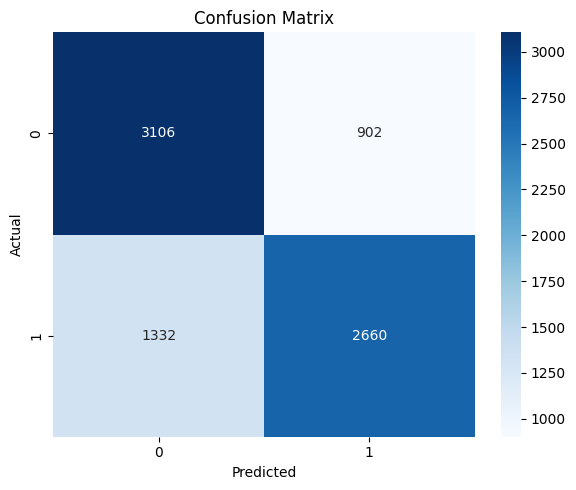

/opt/homebrew/Caskroom/miniconda/base/envs/snn-env/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [18]:
# ====================================
# Step 5: Evaluation and Visualization
# ====================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classifier Accuracy:", acc)
print("Classifier F1 Score:", f1)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# Save Model
clf_model.save("snn_classifier_model.h5")

In [20]:
print("Train label distribution:")
print(pd.Series(y_train).value_counts())


Train label distribution:
0.0    16031
1.0    15969
Name: count, dtype: int64


In [21]:
# =========================================
# learn threshold from validation set
# ========================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, f1_score, classification_report
import numpy as np
# -------------------------------------------------------
# Step 1: Create pseudo-validation set from training data
# -------------------------------------------------------
diff_train_full = np.abs(x1_train - x2_train)
diff_test = np.abs(x1_test - x2_test)

# Split 80% train / 20% val for threshold tuning
diff_train_final, diff_val, y_train_final, y_val = train_test_split(
    diff_train_full, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# -------------------------------------------------------
# Step 2: Build and Train MLP Classifier
# -------------------------------------------------------
input_diff = Input(shape=(diff_train_final.shape[1],))
x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_diff)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
output = Dense(1, activation='sigmoid')(x)
clf_model = Model(inputs=input_diff, outputs=output)

clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
clf_model.fit(diff_train_final, y_train_final, epochs=30, batch_size=256, validation_split=0.1)

# -------------------------------------------------------
# Step 3: Tune threshold on the validation set
# -------------------------------------------------------
y_val_prob = clf_model.predict(diff_val).flatten()

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_val = (y_val_prob >= threshold).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(y_val, y_pred_val, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n Best Threshold (on pseudo-val set): {best_threshold:.2f} — Best F1 Score: {best_f1:.4f}")

# -------------------------------------------------------
# Step 4: Evaluate on the true test set using tuned threshold
# -------------------------------------------------------
y_test_prob = clf_model.predict(diff_test).flatten()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\n Final Evaluation on Test Set:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nDetailed Report:\n", classification_report(y_test, y_test_pred))

# Save predictions
import pandas as pd
pd.DataFrame({
    "True Label": y_test,
    "Predicted Label": y_test_pred,
    "Confidence": y_test_prob
}).to_csv("final_test_predictions.csv", index=False)
print(" Test predictions saved to 'final_test_predictions.csv'")


Epoch 1/30


2026-09-17 13:01:05.242111: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


90/90 [==============================] - 2s 12ms/step - loss: 1.3050 - accuracy: 0.7391 - val_loss: 0.7517 - val_accuracy: 0.8383
Epoch 2/30
 7/90 [=>............................] - ETA: 0s - loss: 0.7533 - accuracy: 0.8348

2026-09-17 13:01:06.908449: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


90/90 [==============================] - 1s 10ms/step - loss: 0.6199 - accuracy: 0.8467 - val_loss: 0.5173 - val_accuracy: 0.8645
Epoch 3/30
90/90 [==============================] - 1s 10ms/step - loss: 0.4720 - accuracy: 0.8612 - val_loss: 0.4117 - val_accuracy: 0.8871
Epoch 4/30
90/90 [==============================] - 1s 11ms/step - loss: 0.4121 - accuracy: 0.8730 - val_loss: 0.3762 - val_accuracy: 0.8879
Epoch 5/30
90/90 [==============================] - 1s 10ms/step - loss: 0.3943 - accuracy: 0.8720 - val_loss: 0.3730 - val_accuracy: 0.8836
Epoch 6/30
90/90 [==============================] - 1s 10ms/step - loss: 0.3785 - accuracy: 0.8747 - val_loss: 0.3531 - val_accuracy: 0.8930
Epoch 7/30
90/90 [==============================] - 1s 10ms/step - loss: 0.3821 - accuracy: 0.8707 - val_loss: 0.3490 - val_accuracy: 0.8930
Epoch 8/30
90/90 [==============================] - 1s 11ms/step - loss: 0.3858 - accuracy: 0.8671 - val_loss: 0.3722 - val_accuracy: 0.8691
Epoch 9/30
90/90 [======

2026-09-17 13:01:34.334580: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


200/200 [==============================] - 0s 1ms/step

 Best Threshold (on pseudo-val set): 0.39 — Best F1 Score: 0.8935
250/250 [==============================] - 0s 971us/step

 Final Evaluation on Test Set:
Accuracy: 0.8885
F1 Score: 0.8889

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.89      0.88      0.89      4008
         1.0       0.88      0.89      0.89      3992

    accuracy                           0.89      8000
   macro avg       0.89      0.89      0.89      8000
weighted avg       0.89      0.89      0.89      8000

 Test predictions saved to 'final_test_predictions.csv'


In [ ]:
## To be added, K attack models 